# 2026 World Cup — Dixon-Coles model & simulation

An interactive walkthrough of the whole pipeline: load the match data, fit the Dixon-Coles goal model, inspect it, predict individual matches, then Monte-Carlo simulate the tournament.

The heavy code lives in three modules under `src/`:

- `dixon_coles.py` — the model (loading, fitting, prediction)
- `wc2026_config.py` — the official 2026 draw and bracket
- `simulate_wc2026.py` — the tournament simulation

This notebook **imports** those modules and drives them step by step, so they stay the single source of truth — anything you change in a `.py` file is picked up here after *Kernel → Restart & Run All*.

**Before running this:** `model_data_cleaning.py` and `elo.py` must have been run — they produce `modeling_matrices_package.zip`, which every step below depends on.

## 1. Setup

Locate the project, put `src/` on the import path, and load the two model modules. The cell prints whether the modelling package exists — if it says `False`, run the cleaning pipeline first.

In [3]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd

# Find the project root by walking up until we see src/dixon_coles.py, so the
# notebook works whether it is launched from notebooks/ or from the root.
BASE_DIR = Path.cwd()
while not (BASE_DIR / 'src' / 'dixon_coles.py').exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent
sys.path.insert(0, str(BASE_DIR / 'src'))

DATA = BASE_DIR / 'data' / 'processed' / 'modeling'
ZIP_PATH = DATA / 'modeling_matrices_package.zip'

import dixon_coles as dc
import wc2026_config as cfg

print('project root :', BASE_DIR)
print('modelling zip:', ZIP_PATH.name, '- exists:', ZIP_PATH.exists())
print('teams in 2026 draw:', sum(len(v) for v in cfg.GROUPS.values()))

project root : /home/vlad/github/Personal/fifa_wc_2026_pred
modelling zip: modeling_matrices_package.zip - exists: True
teams in 2026 draw: 48


## 2. Load the match data

`load_matches` reads `train.csv` + `test.csv` out of the modelling zip, keeps the six columns the model needs, coerces types, and drops everything before `MIN_DATE` (old games carry near-zero time-decay weight anyway). `use_all=True` combines both splits — that is what you want for the real forecast.

In [4]:
matches = dc.load_matches(ZIP_PATH, use_all=True)
span = f'{matches.date.min().date()} to {matches.date.max().date()}'
print(f'{len(matches):,} completed matches loaded ({span})')
matches.tail(8)

11,670 completed matches loaded (2014-01-01 to 2026-03-31)


,date,home_team,away_team,home_score,away_score,neutral
11662,2026-03-31,Bosnia and Herzegovina,Italy,1,1,False
11663,2026-03-31,Sweden,Poland,3,2,False
11664,2026-03-31,Kosovo,Turkey,0,1,False
11665,2026-03-31,Peru,Honduras,2,2,True
11666,2026-03-31,Cameroon,China PR,2,0,True
11667,2026-03-31,Ukraine,Albania,1,0,True
11668,2026-03-31,Ivory Coast,Scotland,1,0,True
11669,2026-03-31,Kazakhstan,Comoros,1,0,False


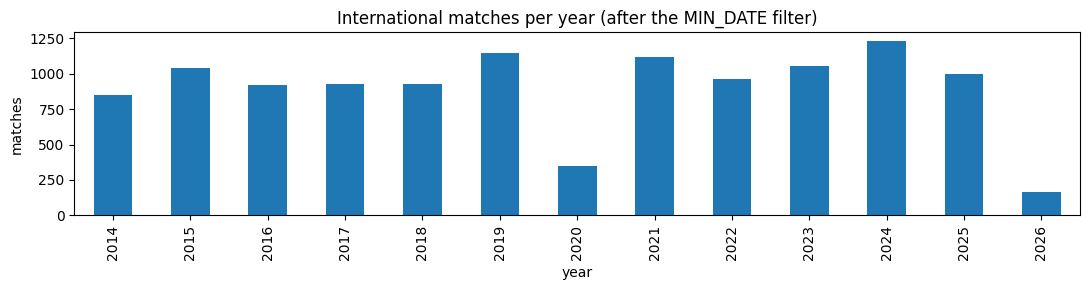

In [5]:
import matplotlib.pyplot as plt

per_year = matches.groupby(matches.date.dt.year).size()
ax = per_year.plot(kind='bar', figsize=(11, 3))
ax.set_title('International matches per year (after the MIN_DATE filter)')
ax.set_xlabel('year'); ax.set_ylabel('matches')
plt.tight_layout(); plt.show()

## 3. Fit the Dixon-Coles model

Three knobs control the fit:

- **`XI`** — the time-decay rate per day. Bigger = recent matches matter more. `0.0018` is roughly a one-year half-life. Section 6 can tune this for you.
- **`RIDGE`** — regularisation that shrinks rarely-seen teams toward an average team. Keeps minnows stable.
- **`PREDICTION_DATE`** — decay is measured backwards from this date.

Edit them, then run the fit cell. The fit minimises the time-weighted negative log-likelihood with L-BFGS-B and typically takes **one to three minutes** — the optimiser prints its progress.

In [6]:
# --- model knobs: edit, then re-run the fit cell below -----------------
XI = 0                       # time-decay rate per day (half-life ~1 year)
RIDGE = 0.01                      # regularisation strength toward an average team
PREDICTION_DATE = '2026-06-11'    # decay is measured backwards from here

print('XI =', XI, '| RIDGE =', RIDGE, '| as-of', PREDICTION_DATE)

XI = 0 | RIDGE = 0.01 | as-of 2026-06-11


In [7]:
t0 = time.time()
design = dc.build_design(matches, PREDICTION_DATE, XI)
model = dc.fit(design, ridge=RIDGE)
model.xi = XI
n_teams = len(design['teams'])
print(f'fitted {n_teams} teams in {time.time() - t0:.0f}s')

  Fitting 578 parameters on 11,670 matches ...
  Optimiser converged; final -log L = 15,753.2
fitted 288 teams in 32s


## 4. Inspect the fitted parameters

Every team has an **attack** and a **defence** value. Higher attack is better; a more *negative* defence is better (it suppresses the opponent), so a natural one-number rating is `attack - defence`. There are also two global parameters: `home_advantage` and `rho` (the low-score correction).

In [8]:
dc.print_diagnostics(model, top_n=20)


FITTED DIXON-COLES PARAMETERS
Home advantage : +0.253  (home team's expected goals multiplied by 1.29)
rho (low-score): -0.046  (draws upweighted)

Top 20 teams by overall strength (attack - defence):
  Team                         Attack  Defence  Strength
  Brazil                       +1.557   -1.562    +3.119
  Spain                        +1.579   -1.396    +2.974
  Argentina                    +1.438   -1.527    +2.966
  England                      +1.370   -1.453    +2.823
  France                       +1.475   -1.326    +2.801
  Portugal                     +1.434   -1.312    +2.745
  Belgium                      +1.482   -1.166    +2.648
  Colombia                     +1.323   -1.315    +2.638
  Germany                      +1.492   -1.071    +2.563
  Netherlands                  +1.440   -1.103    +2.543
  Italy                        +1.203   -1.263    +2.466
  Uruguay                      +1.181   -1.240    +2.422
  Denmark                      +1.174   -1.195    +2.369


In [9]:
rows = [
    {'team': t,
     'attack': model.attack[t],
     'defence': model.defence[t],
     'strength': model.attack[t] - model.defence[t]}
    for t in model.attack
]
strength = (pd.DataFrame(rows)
            .sort_values('strength', ascending=False)
            .reset_index(drop=True))
strength.head(20)

,team,attack,defence,strength
0,Brazil,1.557090,-1.561779,3.118868
1,Spain,1.578772,-1.395547,2.974320
2,Argentina,1.438399,-1.527434,2.965833
3,England,1.369663,-1.453016,2.822679
4,France,1.474836,-1.326450,2.801286
5,Portugal,1.433518,-1.311916,2.745433
6,Belgium,1.482084,-1.165712,2.647796
7,Colombia,1.323408,-1.314591,2.637999
8,Germany,1.492022,-1.070518,2.562540
9,Netherlands,1.440140,-1.103353,2.543492


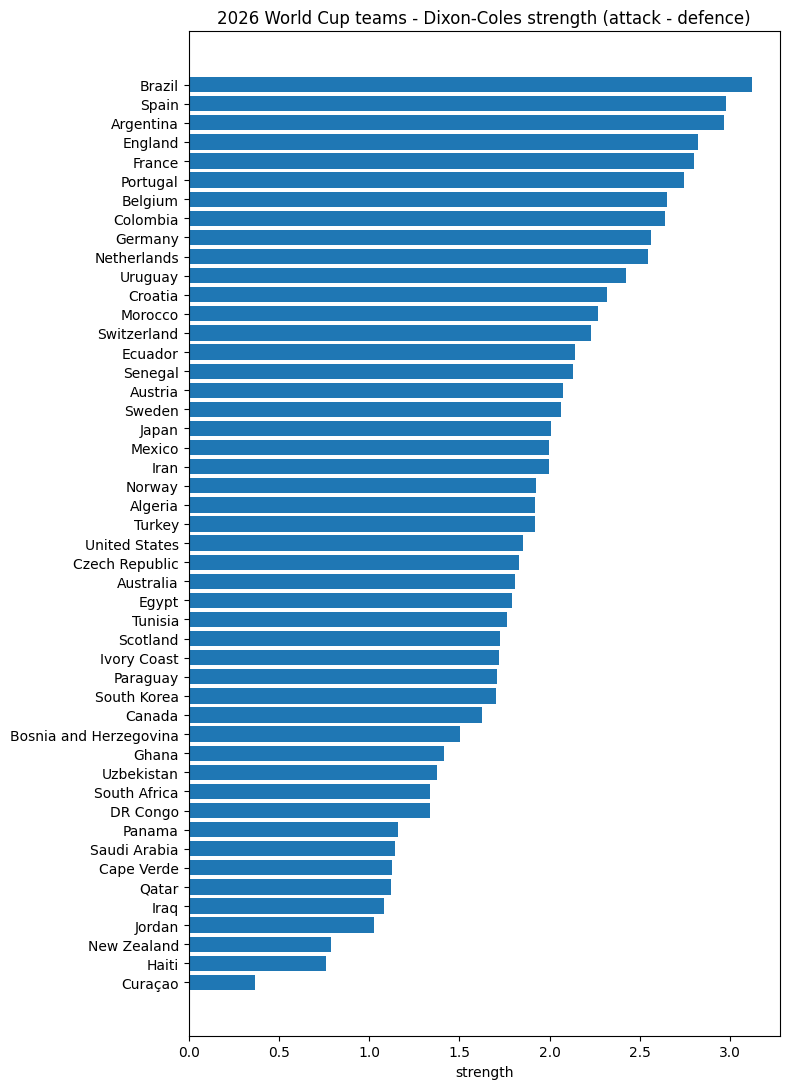

In [10]:
# Strength of just the 48 teams in the 2026 field.
wc_teams = [t for grp in cfg.GROUPS.values() for t in grp]
sub = strength[strength.team.isin(wc_teams)].sort_values('strength')

missing = sorted(set(wc_teams) - set(strength.team))
if missing:
    print('not found in the model - fix spelling in cfg.NAME_ALIASES:', missing)

plt.figure(figsize=(8, 11))
plt.barh(sub.team, sub.strength)
plt.title('2026 World Cup teams - Dixon-Coles strength (attack - defence)')
plt.xlabel('strength')
plt.tight_layout(); plt.show()

## 5. Predict a single match

Given two teams the model produces expected goals for each side, a full grid of scoreline probabilities, and win / draw / loss probabilities. Set `neutral=True` (the World Cup norm) to drop home advantage. Edit `HOME` and `AWAY` and re-run.

In [11]:
# --- pick any two teams (names must match results.csv spelling) --------
HOME, AWAY = 'Spain', 'France'

lam, mu = model.expected_goals(HOME, AWAY, neutral=True)
p = model.outcome_probabilities(HOME, AWAY, neutral=True)
hw, draw, aw = p['home_win'], p['draw'], p['away_win']

print(f'{HOME} vs {AWAY}  (neutral venue)')
print(f'  expected goals : {lam:.2f} - {mu:.2f}')
print(f'  P({HOME} win)  : {hw:.1%}')
print(f'  P(draw)        : {draw:.1%}')
print(f'  P({AWAY} win)  : {aw:.1%}')

Spain vs France  (neutral venue)
  expected goals : 1.29 - 1.08
  P(Spain win)  : 40.5%
  P(draw)        : 28.9%
  P(France win)  : 30.6%


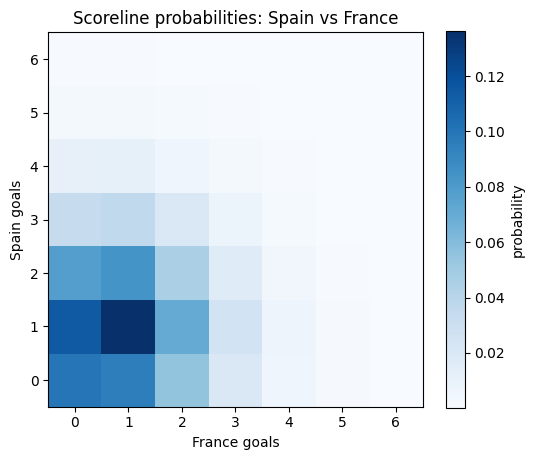

In [12]:
# Scoreline-probability heatmap for the same matchup.
grid = model.score_matrix(HOME, AWAY, neutral=True, max_goals=6)

plt.figure(figsize=(5.5, 4.6))
plt.imshow(grid, origin='lower', cmap='Blues')
plt.colorbar(label='probability')
plt.xticks(range(7)); plt.yticks(range(7))
plt.xlabel(f'{AWAY} goals'); plt.ylabel(f'{HOME} goals')
plt.title(f'Scoreline probabilities: {HOME} vs {AWAY}')
plt.tight_layout(); plt.show()

## 6. (Optional) Tune the time-decay rate

`tune_decay` fits the model at several `XI` values and keeps whichever best forecasts the held-out 2022+ test split. It does **one full re-fit per grid point**, so it is slow. Uncomment to run, then copy the winning value into the knobs cell in section 3 and re-fit.

In [ ]:
# Slow - uncomment to run.
#best_xi, xi_scores = dc.tune_decay(ZIP_PATH)
#print('best XI =', best_xi)

Tuning time-decay rate XI:


KeyboardInterrupt: 

## 7. Save the fitted model

Write the parameters to `dixon_coles_params.json`. The simulation can either use the in-memory `model` object directly (as below) or reload it from this file later.

In [14]:
PARAMS_PATH = DATA / 'dixon_coles_params.json'
model.save(PARAMS_PATH)
print('saved fitted parameters ->', PARAMS_PATH)

saved fitted parameters -> /home/vlad/github/Personal/fifa_wc_2026_pred/data/processed/modeling/dixon_coles_params.json


## 8. Simulate the World Cup

One simulation plays the whole tournament: 12 group round-robins, ranking and the eight best third-placed teams, then the knockout bracket where a level match goes to extra time and, if needed, an explicit penalty shootout. Running it thousands of times turns play-throughs into probabilities.

**`HOST_ADVANTAGE_FRACTION`** sets how much of the home-advantage term the three hosts get in their group games (`0.5` = half, `0.0` = fully neutral). `_cdf_cache.clear()` matters: the simulation caches scoreline distributions, so the cache must be dropped whenever you re-fit the model.

In [15]:
import simulate_wc2026 as sim

# --- simulation knobs --------------------------------------------------
sim.HOST_ADVANTAGE_FRACTION = 0.5      # host edge in group games; 0.0 = neutral

sim.NAME_MAP = sim.resolve_team_names(model)   # 2026 draw names -> model names
sim._cdf_cache.clear()                         # drop score cache from any old model

print('all', len(sim.NAME_MAP), 'teams matched to the model')
print('host advantage fraction:', sim.HOST_ADVANTAGE_FRACTION)

all 48 teams matched to the model
host advantage fraction: 0.5


In [16]:
N_SIMS = 20000      # quick default for iterating; use 20000+ for final numbers

t0 = time.time()
predictions = sim.run(model, N_SIMS)
print(f'{N_SIMS:,} tournaments simulated in {time.time() - t0:.0f}s')
predictions.head(16)

  2,000 / 20,000 simulations done
  4,000 / 20,000 simulations done
  6,000 / 20,000 simulations done
  8,000 / 20,000 simulations done
  10,000 / 20,000 simulations done
  12,000 / 20,000 simulations done
  14,000 / 20,000 simulations done
  16,000 / 20,000 simulations done
  18,000 / 20,000 simulations done
  20,000 / 20,000 simulations done
20,000 tournaments simulated in 8s


,team,group,P(win group),P(advance),P(round of 16),P(quarter-final),P(semi-final),P(final),P(champion)
0,Brazil,C,0.76305,0.99350,0.77540,0.58985,0.41485,0.26580,0.17015
1,Spain,H,0.71180,0.98825,0.69375,0.46745,0.33135,0.21355,0.12395
2,Argentina,J,0.71005,0.98170,0.63655,0.46900,0.31690,0.18790,0.11295
3,France,I,0.65730,0.96875,0.72500,0.46920,0.30100,0.16990,0.09050
4,England,L,0.64015,0.97430,0.69605,0.48545,0.28055,0.16250,0.08875
5,Portugal,K,0.51960,0.95955,0.68125,0.44250,0.25440,0.13815,0.07340
6,Belgium,G,0.66305,0.97115,0.72370,0.48035,0.24120,0.13085,0.06205
7,Colombia,K,0.42325,0.93985,0.62545,0.37375,0.20400,0.10140,0.04990
8,Germany,E,0.63005,0.98895,0.70200,0.36545,0.21175,0.10285,0.04585
9,Netherlands,F,0.51480,0.89245,0.47995,0.32620,0.17770,0.08535,0.03800


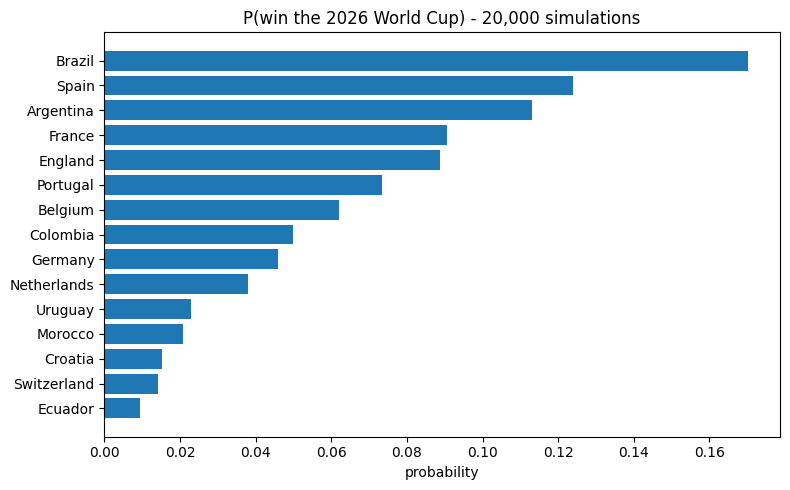

In [17]:
top = predictions.head(15)[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top.team, top['P(champion)'])
plt.xlabel('probability')
plt.title(f'P(win the 2026 World Cup) - {N_SIMS:,} simulations')
plt.tight_layout(); plt.show()

## 9. Dig into a group

Filter the forecast to one group to see how it is likely to play out. Change `GROUP` to any letter A–L.

In [23]:
GROUP = 'D'        # <-- edit to any group letter A-L

cols = ['team', 'P(win group)', 'P(advance)', 'P(round of 16)',
        'P(quarter-final)', 'P(semi-final)', 'P(champion)']
view = predictions[predictions.group == GROUP][cols].reset_index(drop=True)
view.style.format({c: '{:.1%}' for c in cols[1:]})

,team,P(win group),P(advance),P(round of 16),P(quarter-final),P(semi-final),P(champion)
0,United States,31.7%,75.6%,33.7%,11.4%,3.5%,0.3%
1,Turkey,28.7%,73.0%,33.9%,11.5%,3.5%,0.3%
2,Australia,21.8%,65.8%,26.6%,8.5%,2.4%,0.2%
3,Paraguay,17.9%,60.5%,23.5%,7.0%,1.9%,0.1%


## 10. Save the forecast

In [19]:
PRED_PATH = DATA / 'wc2026_predictions.csv'
predictions.to_csv(PRED_PATH, index=False)
print('saved predictions ->', PRED_PATH)

saved predictions -> /home/vlad/github/Personal/fifa_wc_2026_pred/data/processed/modeling/wc2026_predictions.csv


---

### Where to go from here

- **Iterate fast:** keep `N_SIMS` at 5000 while experimenting; raise it to 20000+ only for final numbers.
- **Re-fitting:** if you change `XI` or `RIDGE`, re-run sections 3, 7 and 8 — and remember section 8 clears the score cache for you.
- **Name mismatches:** if section 8 raises a `KeyError`, add the team to `NAME_ALIASES` in `wc2026_config.py` and re-run.
- **Compare assumptions:** run section 8 once with `sim.HOST_ADVANTAGE_FRACTION = 0.0` and once with `0.5` and diff the host nations — that gap is exactly the host effect you are pricing in.